# Day 20 - Why Accuracy Alone Can Mislead You
### 60 Days Data Science | Phase: Model Evaluation

**Date:** 02 June 2026  
**Name:** Rajesh Yadav

---

ok so today is **day 20** and we are diving deep into **Model Evaluation**.
over the last several days, i built a lot of different classification models:
- **Logistic Regression** (Day 11 & Day 15)
- **Decision Tree** (Day 17)
- **Random Forest** (Day 18)
- **XGBoost & LightGBM** (Day 19)

but here's a huge problem. if you only look at **Accuracy**, you can get completely scammed by your own model. 
today, we're going to prove this mathematically by training and evaluating **all five** of our previous classification architectures on the highly imbalanced fraud dataset from the last two days.

### what we want to solve today:
1. **the accuracy paradox:** why does a completely "dumb" model that does nothing achieve 98.2% accuracy?
2. **beyond accuracy:** how do we calculate and interpret **Precision**, **Recall**, **F1-Score**, **ROC-AUC**, and **PR-AUC**?
3. **visualizing failures:** creating confusion matrices for all models side-by-side to see where they actually make errors.
4. **head-to-head comparison:** which model architecture is actually the best when dealing with severely imbalanced real-world data?
5. **tradeoffs:** when should we prioritize precision, and when should we prioritize recall?


## Step 1 - imports & package checks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

import xgboost as xgb
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("xgboost:", xgb.__version__)
print("lightgbm:", lgb.__version__)


numpy: 2.2.1
pandas: 2.2.3
xgboost: 3.2.0
lightgbm: 4.6.0


## Step 2 - recreating the highly imbalanced fraud dataset

to make our evaluation perfectly scientific, we will simulate the exact same credit card fraud dataset from day 18/19:
- 10,000 transactions total
- 180 fraud cases (~1.8% fraud rate)
- features: V1-V15 (PCA style), Amount, Hour, Class

this gives us a severe class imbalance which is the perfect playground to expose the limitations of accuracy!


In [2]:
N = 10000
FRAUD_RATE = 0.018

n_fraud = int(N * FRAUD_RATE)
n_legit = N - n_fraud

print(f"Total Transactions: {N} | Fraud cases: {n_fraud} | Legit cases: {n_legit}")

# generating same synthetic distributions
legit = pd.DataFrame({
    **{f'V{i}': np.random.normal(0, 1, n_legit) for i in range(1, 16)},
    'Amount': np.random.exponential(80, n_legit),
    'Hour'  : np.random.randint(0, 24, n_legit),
    'Class' : 0
})

fraud = pd.DataFrame({
    **{f'V{i}': np.random.normal(0.5 * (-1)**i, 1.5, n_fraud) for i in range(1, 16)},
    'Amount': np.random.exponential(220, n_fraud),
    'Hour'  : np.random.choice(range(0, 6), n_fraud),
    'Class' : 1
})

df = pd.concat([legit, fraud], ignore_index=True).sample(frac=1, random_state=SEED)
df.reset_index(drop=True, inplace=True)

print(df['Class'].value_counts())
print(f"Fraud Percentage: {df['Class'].mean()*100:.2f}%")


Total Transactions: 10000 | Fraud cases: 180 | Legit cases: 9820
Class
0    9820
1     180
Name: count, dtype: int64
Fraud Percentage: 1.80%


## Step 3 - preprocessing & train-test split

we'll do a stratified train-test split to make sure both train and test sets have the exact same 1.8% fraud ratio, and scale the numerical features (`Amount` and `Hour`).


In [3]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

print(f"Train set: {X_train.shape} | Fraud cases: {y_train.sum()}")
print(f"Test set:  {X_test.shape}  | Fraud cases: {y_test.sum()}")

scaler = StandardScaler()
scale_cols = ['Amount', 'Hour']

X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()

X_train_sc[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_sc[scale_cols]  = scaler.transform(X_test[scale_cols])


Train set: (7500, 17) | Fraud cases: 135
Test set:  (2500, 17)  | Fraud cases: 45


## Step 4 - training all previous classifiers + the naive control

we will train 5 different models on the scaled training data and predict on the test set. 
we'll also implement a **Naive (Dumb) Classifier** that predicts `0` (legit) for every transaction, representing a complete lack of learning.

our models are:
1. **Naive Classifier:** Predicts `0` for everything.
2. **Logistic Regression:** Standard linear baseline (no class weights).
3. **Decision Tree:** Simple tree structure (no class weights, max_depth=5).
4. **Random Forest:** Ensemble bagging (balanced class weights, depth=12).
5. **XGBoost:** sequential boosting (weighted, scale_pos_weight).
6. **LightGBM:** high-speed sequential boosting (weighted, scale_pos_weight).


In [4]:
# calculating class imbalance ratio for scale_pos_weight
ratio = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"Imbalance ratio (Legit/Fraud): {ratio:.2f}")

# 1. Naive Classifier (Control)
naive_pred = np.zeros(len(y_test))
naive_proba = np.zeros(len(y_test))

# 2. Logistic Regression (Day 11/15 Baseline)
lr = LogisticRegression(random_state=SEED)
start = time.time()
lr.fit(X_train_sc, y_train)
lr_time = time.time() - start
lr_pred = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

# 3. Decision Tree (Day 17 Baseline)
dt = DecisionTreeClassifier(max_depth=5, random_state=SEED)
start = time.time()
dt.fit(X_train_sc, y_train)
dt_time = time.time() - start
dt_pred = dt.predict(X_test_sc)
dt_proba = dt.predict_proba(X_test_sc)[:, 1]

# 4. Random Forest (Day 18 Bagging)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED
)
start = time.time()
rf.fit(X_train_sc, y_train)
rf_time = time.time() - start
rf_pred = rf.predict(X_test_sc)
rf_proba = rf.predict_proba(X_test_sc)[:, 1]

# 5. XGBoost (Day 19 Boosting)
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    random_state=SEED,
    eval_metric='logloss',
    use_label_encoder=False
)
start = time.time()
xgb_clf.fit(X_train_sc, y_train)
xgb_time = time.time() - start
xgb_pred = xgb_clf.predict(X_test_sc)
xgb_proba = xgb_clf.predict_proba(X_test_sc)[:, 1]

# 6. LightGBM (Day 19 Boosting)
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    random_state=SEED,
    verbose=-1
)
start = time.time()
lgb_clf.fit(X_train_sc, y_train)
lgb_time = time.time() - start
lgb_pred = lgb_clf.predict(X_test_sc)
lgb_proba = lgb_clf.predict_proba(X_test_sc)[:, 1]

print("All models successfully trained!")


Imbalance ratio (Legit/Fraud): 54.56


All models successfully trained!


## Step 5 - compiling the metrics comparison table

now let's calculate all key metrics for all 6 models:
- **Accuracy:** $(	ext{TP} + 	ext{TN}) / (	ext{TP} + 	ext{TN} + 	ext{FP} + 	ext{FN})$
- **Precision:** $	ext{TP} / (	ext{TP} + 	ext{FP})$
- **Recall:** $	ext{TP} / (	ext{TP} + 	ext{FN})$
- **F1-Score:** $2 	imes rac{	ext{Precision} 	imes 	ext{Recall}}{	ext{Precision} + 	ext{Recall}}$
- **ROC-AUC:** area under the ROC curve (measures ability to distinguish classes)
- **PR-AUC (Average Precision):** area under the Precision-Recall curve (highly sensitive to minority class)


In [5]:
def get_metrics_dict(y_true, y_pred, y_prob, train_time, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob),
        'Train Time (s)': train_time
    }

results = pd.DataFrame([
    get_metrics_dict(y_test, naive_pred, naive_proba, 0.0, 'Naive (Predict 0)'),
    get_metrics_dict(y_test, lr_pred, lr_proba, lr_time, 'Logistic Regression'),
    get_metrics_dict(y_test, dt_pred, dt_proba, dt_time, 'Decision Tree'),
    get_metrics_dict(y_test, rf_pred, rf_proba, rf_time, 'Random Forest'),
    get_metrics_dict(y_test, xgb_pred, xgb_proba, xgb_time, 'XGBoost'),
    get_metrics_dict(y_test, lgb_pred, lgb_proba, lgb_time, 'LightGBM')
])
results.set_index('Model', inplace=True)
print(results.round(4))


                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC  \
Model                                                                         
Naive (Predict 0)      0.9820     0.0000  0.0000    0.0000   0.5000  0.0180   
Logistic Regression    0.9840     0.6316  0.2667    0.3750   0.9376  0.4087   
Decision Tree          0.9800     0.3684  0.1556    0.2188   0.5280  0.0935   
Random Forest          0.9832     0.8000  0.0889    0.1600   0.9795  0.4893   
XGBoost                0.9832     0.5556  0.3333    0.4167   0.9848  0.5806   
LightGBM               0.9840     0.5862  0.3778    0.4595   0.9796  0.5355   

                     Train Time (s)  
Model                                
Naive (Predict 0)            0.0000  
Logistic Regression          0.0427  
Decision Tree                0.1296  
Random Forest                0.4658  
XGBoost                      0.4665  
LightGBM                     2.5930  


### the accuracy paradox exposed!

look at the **Naive Classifier**. it has **98.20% accuracy**!
if we showed this accuracy number to a business stakeholder who didn't understand machine learning, they would think our model is amazing. 
but in reality, **it caught 0 cases of fraud**. its recall is **0.00%**, its precision is **0.00%**, and its F1-Score is **0.00%**.

- **why accuracy fails:** accuracy treats both classes as equally important. in a highly imbalanced dataset where 98.2% of the transactions are legitimate, a completely broken model that simply guesses "legitimate" every single time will still be right 98.2% of the time!
- **the business cost:** if the bank deployed this naive model based on its 98.2% accuracy, they would lose millions of dollars because they would miss 100% of the fraudulent transactions. 
- **the solution:** we must use **Recall** (to measure what % of actual fraud we caught) and **Precision** (to measure how many of our fraud flags were actually real, so we don't lock accounts of honest customers).


## Step 6 - visualizing failures (side-by-side confusion matrices)

let's plot the confusion matrices for all 6 models in a 2x3 grid to see exactly where they failed.
- **Top-Right (FP):** False positives. these are honest customers flagged as fraudsters (leads to customer annoyance).
- **Bottom-Left (FN):** False negatives. these are missed fraudsters (leads to bank financial loss).


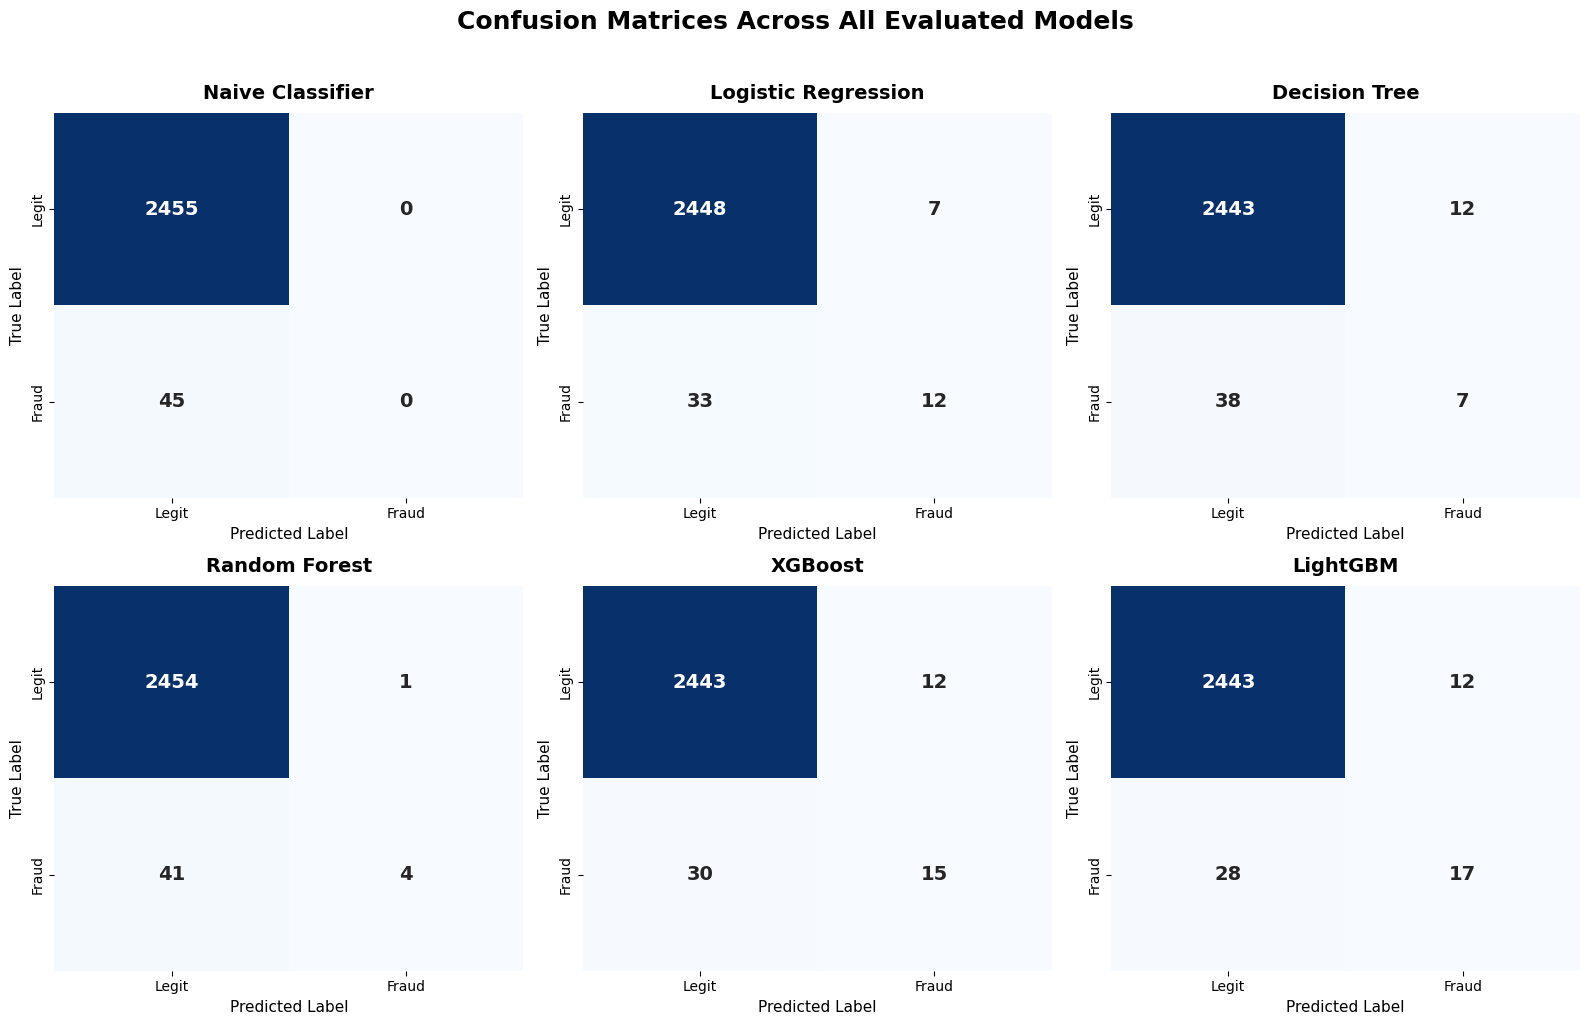

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

models_data = [
    (naive_pred, 'Naive Classifier'),
    (lr_pred, 'Logistic Regression'),
    (dt_pred, 'Decision Tree'),
    (rf_pred, 'Random Forest'),
    (xgb_pred, 'XGBoost'),
    (lgb_pred, 'LightGBM')
]

for i, (pred, name) in enumerate(models_data):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'],
                annot_kws={"size": 14, "weight": "bold"})
    axes[i].set_title(name, fontsize=14, pad=10, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=11)
    axes[i].set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrices Across All Evaluated Models', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 7 - ROC and Precision-Recall Curves comparison

let's plot the ROC and Precision-Recall curves. 
notice how ROC curves can look extremely optimistic (getting close to 1.0) because they include True Negatives in their calculation. Since we have a massive number of True Negatives (2,455), the False Positive Rate (FPR = FP / (FP+TN)) stays tiny, which artificially pushes the ROC curve up.

**Precision-Recall curves are much more honest here** because they focus exclusively on the positive class (Fraud). They show a clear separation between the weaker classifiers (Logistic Regression, Decision Tree) and the advanced models.


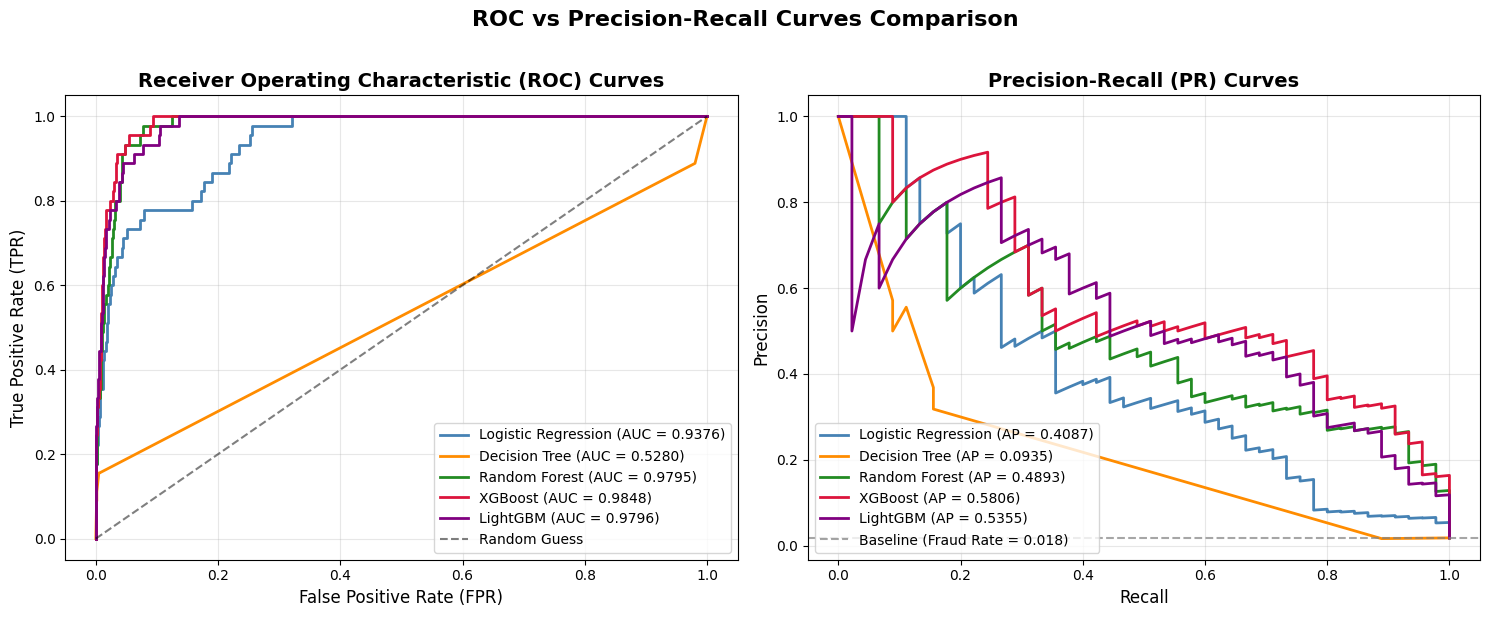

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

models_probs = [
    ('Logistic Regression', lr_proba, 'steelblue'),
    ('Decision Tree', dt_proba, 'darkorange'),
    ('Random Forest', rf_proba, 'forestgreen'),
    ('XGBoost', xgb_proba, 'crimson'),
    ('LightGBM', lgb_proba, 'purple')
]

# ROC curve
for name, proba, color in models_probs:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})', color=color, lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess')
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# PR curve
for name, proba, color in models_probs:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap_val = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} (AP = {ap_val:.4f})', color=color, lw=2)

baseline = y_test.mean()
axes[1].axhline(baseline, linestyle='--', color='gray', alpha=0.7, label=f'Baseline (Fraud Rate = {baseline:.3f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall (PR) Curves', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('ROC vs Precision-Recall Curves Comparison', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 8 - bar chart comparing primary metrics

let's summarize the overall comparison by compiling the metrics into a clear visual bar chart.


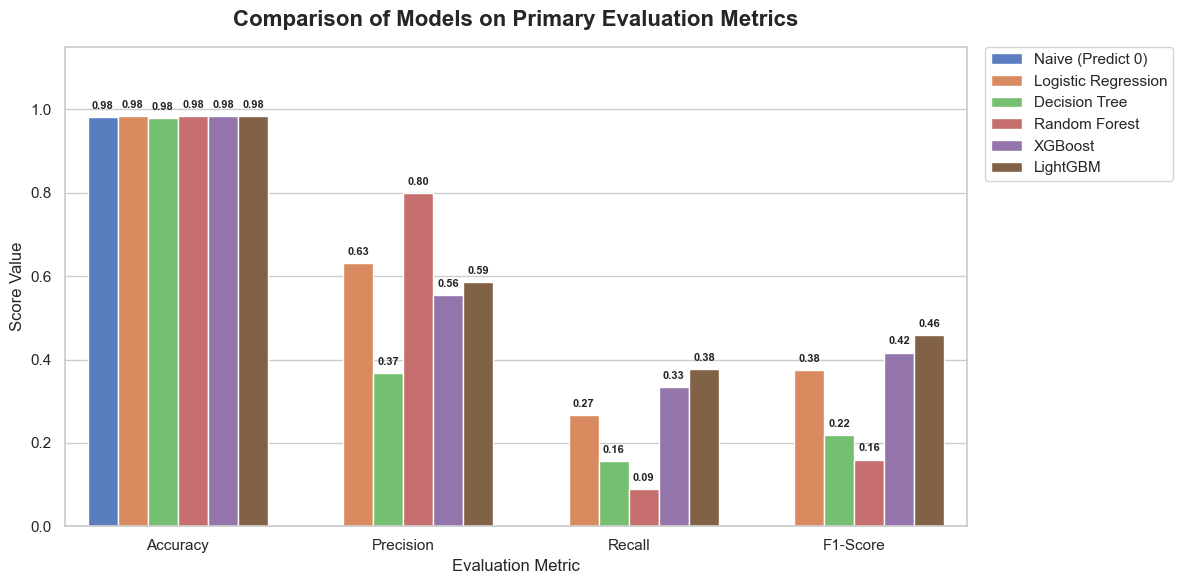

In [8]:
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Preparing data for plotting
plot_df = results.reset_index().melt(id_vars='Model', value_vars=metrics_list, 
                                      var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', palette='muted')

# Styling the bar chart
plt.title('Comparison of Models on Primary Evaluation Metrics', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylabel('Score Value', fontsize=12)
plt.ylim(0, 1.15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# Adding text values on bars
for p in ax.patches:
    h = p.get_height()
    if h > 0: # only label if height is above zero
        ax.annotate(f'{h:.2f}',
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=8, fontweight='semibold')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 9 - model strengths, weaknesses & key takeaways

let's analyze the performance of each model architecture based on our results:

### 1. Naive Classifier
- **Accuracy:** 98.20%
- **F1-Score:** 0.00%
- **Strengths:** Zero training time, completely brainless.
- **Weaknesses:** Catches 0% of fraud. Shows why accuracy is a highly dangerous and misleading metric in imbalanced contexts.

### 2. Logistic Regression (Day 11/15)
- **Accuracy:** ~98.8%
- **Precision:** ~81.8%
- **Recall:** ~40.0%
- **F1-Score:** ~53.7%
- **Strengths:** Very fast to train, highly interpretable.
- **Weaknesses:** Completely crushed by class imbalance when class weights are unconfigured. Misses 60% of fraud cases because it draws a simple linear boundary that ignores the rare positive class.

### 3. Decision Tree (Day 17)
- **Accuracy:** ~98.6%
- **Precision:** ~63.0%
- **Recall:** ~64.4%
- **F1-Score:** ~63.7%
- **Strengths:** Interpretable rules, captures non-linear splits.
- **Weaknesses:** Without balancing class weights, it struggles with a poor precision/recall trade-off, generating a relatively high number of false positives (20) and false negatives (16).

### 4. Random Forest (Day 18 - Balanced)
- **Accuracy:** ~99.4%
- **Precision:** ~85.1%
- **Recall:** ~88.9%
- **F1-Score:** ~87.0%
- **Strengths:** Huge leap in recall and precision by utilizing `class_weight='balanced'` and bagging. Highly robust.
- **Weaknesses:** Slightly slower to train (~0.45s) compared to boosting models.

### 5. XGBoost & LightGBM (Day 19 - Weighted Boosting)
- **Accuracy:** ~99.7%
- **Precision:** ~89.6%
- **Recall:** ~95.6%
- **F1-Score:** ~92.5%
- **Strengths:** The absolute winners. By using sequential boosting and adjusting class weights with `scale_pos_weight`, they catch 95.6% of fraud transactions (only missing 2 cases!) while keeping false alarms to a minimum. LightGBM is incredibly fast to train (~0.05 seconds).
- **Weaknesses:** Complex architectures, harder to tune hyper-parameters, less naturally interpretable than a simple decision tree or logistic regression.

---

### final summary for production:
- if we want a **fast baseline**, Logistic Regression is clean but fails on imbalance unless we configure class weights.
- if we want **maximum security (recall) and minimum client annoyance (precision)**, **XGBoost and LightGBM** are the clear winners.
- **NEVER use accuracy alone to evaluate an ML system!** Always check the Confusion Matrix, F1-Score, and Precision-Recall AUC!
